In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
import random


2026-02-25 14:42:04.242117: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = y_train.squeeze()
y_test = y_test.squeeze()

/home/maxmaster/data/ITI/ai/.venv/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [4]:
CANVAS_SIZE = 96
OBJ_SIZE = 32

In [5]:
def create_sample(image, label):
    canvas = np.zeros((CANVAS_SIZE, CANVAS_SIZE, 3), dtype=np.float32)
    
    # Random top-left position
    max_pos = CANVAS_SIZE - OBJ_SIZE
    x1 = random.randint(0, max_pos)
    y1 = random.randint(0, max_pos)
    
    x2 = x1 + OBJ_SIZE
    y2 = y1 + OBJ_SIZE
    
    # Paste image
    canvas[y1:y2, x1:x2, :] = image
    
    # Normalize bounding box
    bbox = np.array([
        x1 / CANVAS_SIZE,
        y1 / CANVAS_SIZE,
        x2 / CANVAS_SIZE,
        y2 / CANVAS_SIZE
    ], dtype=np.float32)
    
    return canvas, label, bbox

In [6]:
def build_dataset(images, labels, num_samples):
    X = []
    Y_class = []
    Y_bbox = []
    
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    for idx in indices:
        canvas, label, bbox = create_sample(images[idx], labels[idx])
        X.append(canvas)
        Y_class.append(label)
        Y_bbox.append(bbox)
    
    return np.array(X), np.array(Y_class), np.array(Y_bbox)

In [7]:
X_train, y_train_cls, y_train_bbox = build_dataset(x_train, y_train, 8000)
X_test, y_test_cls, y_test_bbox = build_dataset(x_test, y_test, 2000)

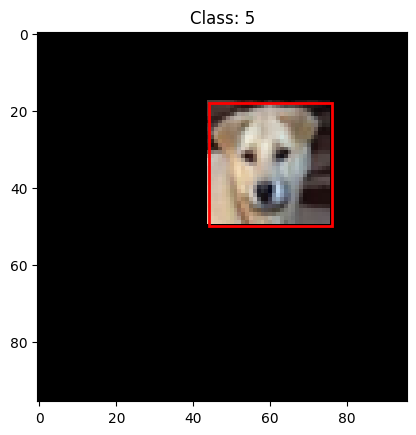

In [8]:
def visualize_sample(image, bbox, label):
    plt.imshow(image)
    
    x1 = int(bbox[0] * CANVAS_SIZE)
    y1 = int(bbox[1] * CANVAS_SIZE)
    x2 = int(bbox[2] * CANVAS_SIZE)
    y2 = int(bbox[3] * CANVAS_SIZE)
    
    plt.gca().add_patch(
        plt.Rectangle((x1, y1),
                      x2-x1,
                      y2-y1,
                      fill=False,
                      edgecolor='red',
                      linewidth=2)
    )
    
    plt.title(f"Class: {label}")
    plt.show()

visualize_sample(X_train[0], y_train_bbox[0], y_train_cls[0])

In [67]:
inputs = tf.keras.Input(shape=(96, 96, 3))

# Shared Backbone
x = tf.keras.layers.Conv2D(128, 3, activation='relu')(inputs)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(64, 3, activation='relu')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Conv2D(128, 3, activation='relu')(x)
x = tf.keras.layers.MaxPooling2D()(x)

x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)

# Classification Head
class_output = tf.keras.layers.Dense(10, activation='softmax', name="class_output")(x)

# Bounding Box Head
bbox_output = tf.keras.layers.Dense(4, activation='sigmoid', name="bbox_output")(x)

model = tf.keras.Model(inputs=inputs, outputs=[class_output, bbox_output])

In [68]:
model.compile(
    optimizer='adam',
    loss={
        "class_output": "sparse_categorical_crossentropy",
        "bbox_output": "mse"
    },
    metrics={
        "class_output": "accuracy",
        "bbox_output": "mae"
    }
)

In [69]:
history = model.fit(
    X_train,
    {"class_output": y_train_cls, "bbox_output": y_train_bbox},
    validation_data=(
        X_test,
        {"class_output": y_test_cls, "bbox_output": y_test_bbox}
    ),
    epochs=20,
    batch_size=32
)

Epoch 1/20


2026-02-25 15:07:16.961623: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,94,94]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,96,96]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-25 15:07:17.039284: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,45,45]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,47,47]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - bbox_output_loss: 0.0262 - bbox_output_mae: 0.1237 - class_output_accuracy: 0.1508 - class_output_loss: 2.2342 - loss: 2.2604

2026-02-25 15:07:28.442050: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,94,94]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,3,96,96]{3,2,1,0}, f32[128,3,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-25 15:07:28.525041: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,45,45]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,47,47]{3,2,1,0}, f32[64,128,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivati

250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - bbox_output_loss: 0.0144 - bbox_output_mae: 0.0881 - class_output_accuracy: 0.1834 - class_output_loss: 2.1561 - loss: 2.1705 - val_bbox_output_loss: 0.0096 - val_bbox_output_mae: 0.0742 - val_class_output_accuracy: 0.1985 - val_class_output_loss: 2.0676 - val_loss: 2.0778
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - bbox_output_loss: 0.0043 - bbox_output_mae: 0.0509 - class_output_accuracy: 0.2630 - class_output_loss: 1.9424 - loss: 1.9467 - val_bbox_output_loss: 0.0031 - val_bbox_output_mae: 0.0440 - val_class_output_accuracy: 0.2755 - val_class_output_loss: 1.9094 - val_loss: 1.9132
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 35ms/step - bbox_output_loss: 0.0033 - bbox_output_mae: 0.0447 - class_output_accuracy: 0.3384 - class_output_loss: 1.7658 - loss: 1.7691 - val_bbox_output_loss: 0.0031 - val_bbox_output_mae: 0.0438 - val_class_output_accuracy: 0.3275 - val_class_output_loss: 1.7783 - val_loss: 1.7809
Epoch 4/20
250/250 ━━━━

In [12]:
def compute_iou(box1, box2):
    # box format: (x1, y1, x2, y2)
    
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    union = area1 + area2 - intersection
    
    if union == 0:
        return 0
    
    return intersection / union

In [13]:
pred_class, pred_bbox = model.predict(X_test[:200])

ious = []

for i in range(200):
    iou = compute_iou(y_test_bbox[i], pred_bbox[i])
    ious.append(iou)

print("Mean IoU:", np.mean(ious))

2026-02-25 14:44:30.934560: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 22118400 exceeds 10% of free system memory.


1/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step

2026-02-25 14:44:33.574317: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,32,94,94]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,3,96,96]{3,2,1,0}, f32[32,3,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kRelu","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-02-25 14:44:33.697221: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[8,64,45,45]{3,2,1,0}, u8[0]{0}) custom-call(f32[8,32,47,47]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward

7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 174ms/step
Mean IoU: 0.6360624


In [ ]:
def visualize_prediction(image, true_bbox, pred_bbox, true_label, pred_label):
    plt.imshow(image)
    
    # True box (Green)
    x1 = int(true_bbox[0] * CANVAS_SIZE)
    y1 = int(true_bbox[1] * CANVAS_SIZE)
    x2 = int(true_bbox[2] * CANVAS_SIZE)
    y2 = int(true_bbox[3] * CANVAS_SIZE)
    
    plt.gca().add_patch(
        plt.Rectangle((x1, y1),
                      x2-x1,
                      y2-y1,
                      fill=False,
                      edgecolor='green',
                      linewidth=2)
    )
    
    # Predicted box (Red)
    x1 = int(pred_bbox[0] * CANVAS_SIZE)
    y1 = int(pred_bbox[1] * CANVAS_SIZE)
    x2 = int(pred_bbox[2] * CANVAS_SIZE)
    y2 = int(pred_bbox[3] * CANVAS_SIZE)
    
    plt.gca().add_patch(
        plt.Rectangle((x1, y1),
                      x2-x1,
                      y2-y1,
                      fill=False,
                      edgecolor='red',
                      linewidth=2)
    )
    
    plt.title(f"True: {true_label} | Pred: {pred_label}")
    plt.show()

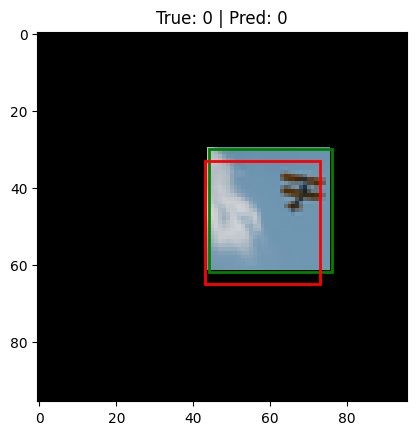

In [66]:
idx = random.randint(0, 199)

visualize_prediction(
    X_test[idx],
    y_test_bbox[idx],
    pred_bbox[idx],
    y_test_cls[idx],
    np.argmax(pred_class[idx])
)